# LSTM with Random Search Hyperparameter Tuning
## Chlorophyll-a Prediction — 13 Features

**Random Search** samples a fixed number of random combinations from the hyperparameter space instead of exhaustively testing all combinations (Grid Search). Much faster and often finds equally good results.

### Hyperparameters searched:
| Parameter | Search Space |
|-----------|-------------|
| `lookback` | 7, 14, 21, 30 |
| `n_lstm_layers` | 1, 2, 3 |
| `lstm_units` | 32, 64, 128 |
| `dropout_rate` | 0.1, 0.2, 0.3 |
| `learning_rate` | 1e-4, 5e-4, 1e-3, 5e-3 |
| `batch_size` | 16, 32, 64 |
| `dense_units` | 8, 16, 32 |

Total possible combinations: **4 × 3 × 3 × 3 × 4 × 3 × 3 = 3,888**  
We randomly sample **N_TRIALS = 20** of them.

---
## CELL 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import random
import time
import itertools
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

%matplotlib inline
print("Libraries loaded.")

Libraries loaded.


---
## CELL 2 — Upload & Load Data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving datafinal_last.csv to datafinal_last.csv


In [23]:
df_raw = pd.read_csv("datafinal_last.csv")
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_raw = df_raw.sort_values('time').reset_index(drop=True)

print(f"Rows: {len(df_raw)}  |  Columns: {list(df_raw.columns)}")
print(df.head())

Rows: 1187  |  Columns: ['time', 'latitude', 'longitude', 'sea_surface_temperature_anomaly', 'chla', 'fe', 'NO3', 'PO4', 'silicate', 'spC02', 'Salinity', 'uo', 'vo', 'wo', 'O2', 'ph']
        time      chla        fe       NO3       PO4  \
0 2022-11-04  0.084785  0.002457  3.662635  0.000061   
1 2022-11-05  0.084976  0.002517  3.698131  0.000059   
2 2022-11-06  0.085219  0.002626  3.709516  0.000063   
3 2022-11-07  0.085788  0.002770  3.768795  0.000063   
4 2022-11-08  0.087006  0.002860  3.871914  0.000063   

   sea_surface_temperature_anomaly  silicate         O2   Salinity        uo  \
0                         0.011631  5.592276  203.78589  28.233946 -0.488317   
1                        -0.287436  6.162067  203.96228  28.159157 -0.410956   
2                        -0.563166  6.440931  204.14618  26.614113 -0.507552   
3                        -0.632668  6.904136  204.30453  23.217772 -0.737328   
4                        -0.646633  7.640750  204.47684  23.231936 -0.746408   

---
## CELL 3 — Preprocessing

### Steps:
1. Select 13 oceanographic features
2. `log1p`-transform `chla` → stabilises the skewed bloom spike distribution
3. Add **cyclic time features** (sin/cos of month and day-of-year) so the model is aware of seasonal bloom cycles
4. Add **lag features** for chla (t-1, t-2, t-3) as the strongest short-term predictors

In [22]:
# 3a. Base 13 oceanographic features
BASE_FEATURES = [
    'chla', 'fe', 'NO3', 'PO4', 'sea_surface_temperature_anomaly',
    'silicate', 'O2', 'Salinity', 'uo', 'vo', 'wo', 'spC02', 'ph'
]

df = df_raw[['time'] + BASE_FEATURES].dropna().reset_index(drop=True)
print(f"After dropna: {df.shape}")

# 3b. Log-transform chla
df['chla_log'] = np.log1p(df['chla'])

# 3c. Cyclic time features ─
df['month']     = df['time'].dt.month
df['doy']       = df['time'].dt.dayofyear
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['doy_sin']   = np.sin(2 * np.pi * df['doy']   / 365)
df['doy_cos']   = np.cos(2 * np.pi * df['doy']   / 365)

# 3d. Lag features
for lag in [1, 2, 3]:
    df[f'chla_log_lag{lag}'] = df['chla_log'].shift(lag)

df = df.dropna().reset_index(drop=True)

# 3e. Final feature list
FEATURE_COLS = [
    # 13 oceanographic (chla_log replaces raw chla)
    'chla_log', 'fe', 'NO3', 'PO4', 'sea_surface_temperature_anomaly',
    'silicate', 'O2', 'Salinity', 'uo', 'vo', 'wo', 'spC02', 'ph',
    # cyclic time
    'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    # lags
    'chla_log_lag1', 'chla_log_lag2', 'chla_log_lag3'
]
TARGET_COL = 'chla_log'

print(f"\nFinal dataset : {df.shape}")
print(f"Feature count : {len(FEATURE_COLS)}")
print(f"Features      : {FEATURE_COLS}")

# Save to CSV
df.to_csv("preprocessed_chla_data.csv", index=False)

# Download
from google.colab import files
files.download("preprocessed_chla_data.csv")

After dropna: (1187, 14)

Final dataset : (1184, 24)
Feature count : 20
Features      : ['chla_log', 'fe', 'NO3', 'PO4', 'sea_surface_temperature_anomaly', 'silicate', 'O2', 'Salinity', 'uo', 'vo', 'wo', 'spC02', 'ph', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'chla_log_lag1', 'chla_log_lag2', 'chla_log_lag3']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

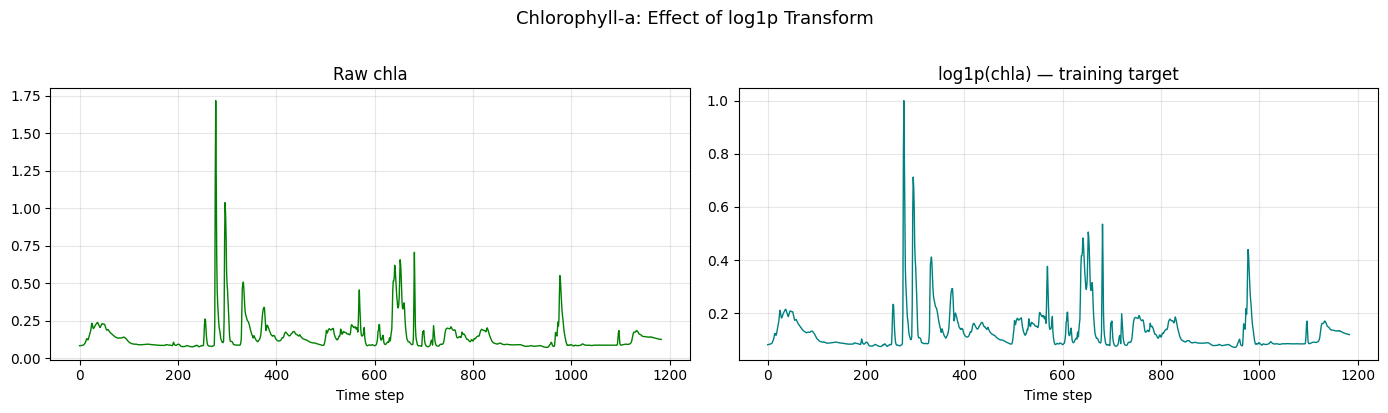

In [6]:
# Quick EDA — raw chla vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df['chla'],     color='green', lw=1); axes[0].set_title('Raw chla')
axes[1].plot(df['chla_log'], color='teal',  lw=1); axes[1].set_title('log1p(chla) — training target')
for ax in axes:
    ax.set_xlabel('Time step'); ax.grid(True, alpha=0.3)
plt.suptitle('Chlorophyll-a: Effect of log1p Transform', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## CELL 4 — Helper Functions

In [7]:
# ── Sequence builder ────────────────────────────────────────────────────────
def make_sequences(X, y, lookback):
    """Sliding-window sequences: X[i-lookback:i] → y[i]."""
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback : i])
        ys.append(y[i, 0])
    return np.array(Xs), np.array(ys)


# ── Dataset builder (split + scale + sequence) ──────────────────────────────
def build_dataset(df, feature_cols, target_col, lookback, train_frac=0.90):
    """
    Returns scaled train/test sequences.
    Scalers are fit on train only — no leakage.
    """
    n = len(df)
    split = int(n * train_frac)

    df_tr = df.iloc[:split].reset_index(drop=True)
    df_te = df.iloc[split:].reset_index(drop=True)

    sx = MinMaxScaler()
    sy = MinMaxScaler()

    X_tr_sc = sx.fit_transform(df_tr[feature_cols])
    y_tr_sc = sy.fit_transform(df_tr[[target_col]])
    X_te_sc = sx.transform(df_te[feature_cols])     # no fit!
    y_te_sc = sy.transform(df_te[[target_col]])

    X_tr_seq, y_tr_seq = make_sequences(X_tr_sc, y_tr_sc, lookback)

    # Prepend last lookback rows from train so test sequences are aligned
    X_te_full = np.vstack([X_tr_sc[-lookback:], X_te_sc])
    y_te_full = np.vstack([y_tr_sc[-lookback:], y_te_sc])
    X_te_seq, y_te_seq = make_sequences(X_te_full, y_te_full, lookback)

    return X_tr_seq, y_tr_seq, X_te_seq, y_te_seq, sy


# ── Model builder from a param dict ─────────────────────────────────────────
def build_model(params, n_features):
    """
    Builds an LSTM model from a hyperparameter dict.
    params keys: lookback, n_lstm_layers, lstm_units,
                 dropout_rate, learning_rate, batch_size, dense_units
    """
    model = Sequential()
    model.add(Input(shape=(params['lookback'], n_features)))

    for layer_i in range(params['n_lstm_layers']):
        return_seq = (layer_i < params['n_lstm_layers'] - 1)  # True for all but last
        model.add(LSTM(params['lstm_units'], return_sequences=return_seq))
        model.add(BatchNormalization())
        model.add(Dropout(params['dropout_rate']))

    model.add(Dense(params['dense_units'], activation='relu'))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=params['learning_rate']),
        loss='mse',
        metrics=['mae']
    )
    return model


# ── Evaluate one trial ───────────────────────────────────────────────────────
def run_trial(params, df, feature_cols, target_col):
    """
    Builds dataset, trains model with given params, returns val_loss + metrics.
    """
    X_tr, y_tr, X_te, y_te, sy = build_dataset(
        df, feature_cols, target_col, params['lookback']
    )
    n_features = X_tr.shape[2]

    model = build_model(params, n_features)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=7, min_lr=1e-6, verbose=0)
    ]

    hist = model.fit(
        X_tr, y_tr,
        epochs=100,                      # capped at 100 for speed during search
        batch_size=params['batch_size'],
        validation_split=0.12,
        callbacks=callbacks,
        verbose=0
    )

    best_val_loss = min(hist.history['val_loss'])

    # Quick test-set evaluation
    y_pred_sc = model.predict(X_te, verbose=0)
    y_pred    = np.expm1(sy.inverse_transform(y_pred_sc))
    y_true    = np.expm1(sy.inverse_transform(y_te.reshape(-1, 1)))

    return {
        'val_loss': best_val_loss,
        'mae':      mean_absolute_error(y_true, y_pred),
        'rmse':     np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2':       r2_score(y_true, y_pred),
        'epochs':   len(hist.history['val_loss'])
    }


print("Helper functions defined.")

Helper functions defined.


---
## CELL 5 — Define Search Space & Sample Random Combinations

In [8]:
# ── Hyperparameter search space ──────────────────────────────────────────────
PARAM_SPACE = {
    'lookback'      : [7, 14, 21, 30],
    'n_lstm_layers' : [1, 2, 3],
    'lstm_units'    : [32, 64, 128],
    'dropout_rate'  : [0.1, 0.2, 0.3],
    'learning_rate' : [1e-4, 5e-4, 1e-3, 5e-3],
    'batch_size'    : [16, 32, 64],
    'dense_units'   : [8, 16, 32]
}

# Total possible combinations
from functools import reduce
import operator
total = reduce(operator.mul, [len(v) for v in PARAM_SPACE.values()])
print(f"Total possible combinations : {total:,}")

# ── How many trials to run ───────────────────────────────────────────────────
N_TRIALS = 20   # ← increase for better coverage (each trial ≈ 1-2 min on GPU)
print(f"Trials to run               : {N_TRIALS}")
print(f"Search coverage             : {N_TRIALS/total*100:.2f}%")

# ── Randomly sample N_TRIALS unique combinations ─────────────────────────────
random.seed(SEED)
sampled_params = []
seen = set()

while len(sampled_params) < N_TRIALS:
    candidate = {k: random.choice(v) for k, v in PARAM_SPACE.items()}
    key = tuple(candidate[k] for k in sorted(candidate))
    if key not in seen:
        seen.add(key)
        sampled_params.append(candidate)

# Display the sampled combinations
df_search = pd.DataFrame(sampled_params)
print(f"\nSampled {N_TRIALS} unique combinations:")
df_search

Total possible combinations : 3,888
Trials to run               : 20
Search coverage             : 0.51%

Sampled 20 unique combinations:


,lookback,n_lstm_layers,lstm_units,dropout_rate,learning_rate,batch_size,dense_units
0,7,1,128,0.2,0.0005,16,8
1,7,3,128,0.3,0.0001,64,16
2,7,1,32,0.1,0.0005,64,32
3,7,3,32,0.3,0.0050,16,16
4,21,1,32,0.3,0.0050,32,16
5,14,1,64,0.1,0.0001,32,8
6,21,2,128,0.2,0.0001,64,16
7,7,2,32,0.3,0.0010,64,32
8,21,3,32,0.3,0.0001,16,32
9,14,2,32,0.1,0.0001,32,16


---
## CELL 6 — Run Random Search

Each trial trains a model with early stopping (max 100 epochs) and records val_loss + test metrics.

In [9]:
results = []
search_start = time.time()

for trial_idx, params in enumerate(sampled_params):
    t0 = time.time()
    print(f"\n{'='*60}")
    print(f"Trial {trial_idx+1:>2}/{N_TRIALS}  |  Params: {params}")

    try:
        metrics = run_trial(params, df, FEATURE_COLS, TARGET_COL)
        result  = {**params, **metrics}
        results.append(result)

        elapsed = time.time() - t0
        print(f"  val_loss={metrics['val_loss']:.6f}  "
              f"MAE={metrics['mae']:.5f}  "
              f"RMSE={metrics['rmse']:.5f}  "
              f"R²={metrics['r2']:.4f}  "
              f"epochs={metrics['epochs']}  "
              f"time={elapsed:.1f}s")

    except Exception as e:
        print(f"  ✗ Trial failed: {e}")

total_time = time.time() - search_start
print(f"\n{'='*60}")
print(f"Random search complete in {total_time/60:.1f} min")


Trial  1/20  |  Params: {'lookback': 7, 'n_lstm_layers': 1, 'lstm_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 16, 'dense_units': 8}
  val_loss=0.001782  MAE=0.02224  RMSE=0.03117  R²=0.0133  epochs=33  time=25.3s

Trial  2/20  |  Params: {'lookback': 7, 'n_lstm_layers': 3, 'lstm_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0001, 'batch_size': 64, 'dense_units': 16}
  val_loss=0.005566  MAE=0.03513  RMSE=0.03867  R²=-0.5190  epochs=19  time=29.6s

Trial  3/20  |  Params: {'lookback': 7, 'n_lstm_layers': 1, 'lstm_units': 32, 'dropout_rate': 0.1, 'learning_rate': 0.0005, 'batch_size': 64, 'dense_units': 32}


  val_loss=0.005028  MAE=0.04041  RMSE=0.05129  R²=-1.6715  epochs=18  time=6.4s

Trial  4/20  |  Params: {'lookback': 7, 'n_lstm_layers': 3, 'lstm_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.005, 'batch_size': 16, 'dense_units': 16}
  val_loss=0.006412  MAE=0.02958  RMSE=0.03487  R²=-0.2346  epochs=22  time=26.4s

Trial  5/20  |  Params: {'lookback': 21, 'n_lstm_layers': 1, 'lstm_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.005, 'batch_size': 32, 'dense_units': 16}
  val_loss=0.005903  MAE=0.02668  RMSE=0.03048  R²=0.0563  epochs=24  time=12.9s

Trial  6/20  |  Params: {'lookback': 14, 'n_lstm_layers': 1, 'lstm_units': 64, 'dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 32, 'dense_units': 8}
  val_loss=0.006395  MAE=0.06714  RMSE=0.07053  R²=-4.0525  epochs=17  time=10.1s

Trial  7/20  |  Params: {'lookback': 21, 'n_lstm_layers': 2, 'lstm_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.0001, 'batch_size': 64, 'dense_units': 16}
  val_loss=0.005695  MAE=

---
## CELL 7 — Analyse Search Results

In [10]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('val_loss').reset_index(drop=True)

print("All trials sorted by validation loss:")
display_cols = list(PARAM_SPACE.keys()) + ['val_loss', 'mae', 'rmse', 'r2', 'epochs']
df_results[display_cols].round(6)

All trials sorted by validation loss:


,lookback,n_lstm_layers,lstm_units,dropout_rate,learning_rate,batch_size,dense_units,val_loss,mae,rmse,r2,epochs
0,7,1,32,0.2,0.0050,32,8,0.000980,0.022940,0.028748,0.160668,45
1,7,1,128,0.2,0.0005,16,8,0.001782,0.022243,0.031169,0.013333,33
2,21,3,128,0.3,0.0001,64,32,0.004439,0.046313,0.053149,-1.868919,20
3,14,3,128,0.1,0.0005,32,16,0.004626,0.026590,0.038731,-0.523523,18
4,7,1,32,0.1,0.0005,64,32,0.005028,0.040413,0.051288,-1.671518,18
5,30,3,64,0.1,0.0010,16,8,0.005101,0.075831,0.090204,-7.263765,18
6,21,3,128,0.2,0.0050,32,8,0.005421,0.029256,0.035124,-0.252936,21
7,14,3,128,0.2,0.0005,64,16,0.005528,0.037306,0.046373,-1.183978,19
8,7,3,128,0.3,0.0001,64,16,0.005566,0.035127,0.038674,-0.519002,19
9,21,3,32,0.3,0.0001,16,32,0.005640,0.027456,0.029075,0.141469,16


In [11]:
# ── Best hyperparameters ──────────────────────────────────────────────────────
best_row    = df_results.iloc[0]
BEST_PARAMS = {k: best_row[k] for k in PARAM_SPACE.keys()}

# Cast integer params back to int (DataFrame may store as float)
for k in ['lookback', 'n_lstm_layers', 'lstm_units', 'batch_size', 'dense_units']:
    BEST_PARAMS[k] = int(BEST_PARAMS[k])

print("\n" + "="*50)
print("  BEST HYPERPARAMETERS FOUND")
print("="*50)
for k, v in BEST_PARAMS.items():
    print(f"  {k:<20}: {v}")
print("-"*50)
print(f"  val_loss   : {best_row['val_loss']:.6f}")
print(f"  Test MAE   : {best_row['mae']:.6f}")
print(f"  Test RMSE  : {best_row['rmse']:.6f}")
print(f"  Test R²    : {best_row['r2']:.4f}")
print("="*50)


  BEST HYPERPARAMETERS FOUND
  lookback            : 7
  n_lstm_layers       : 1
  lstm_units          : 32
  dropout_rate        : 0.2
  learning_rate       : 0.005
  batch_size          : 32
  dense_units         : 8
--------------------------------------------------
  val_loss   : 0.000980
  Test MAE   : 0.022940
  Test RMSE  : 0.028748
  Test R²    : 0.1607


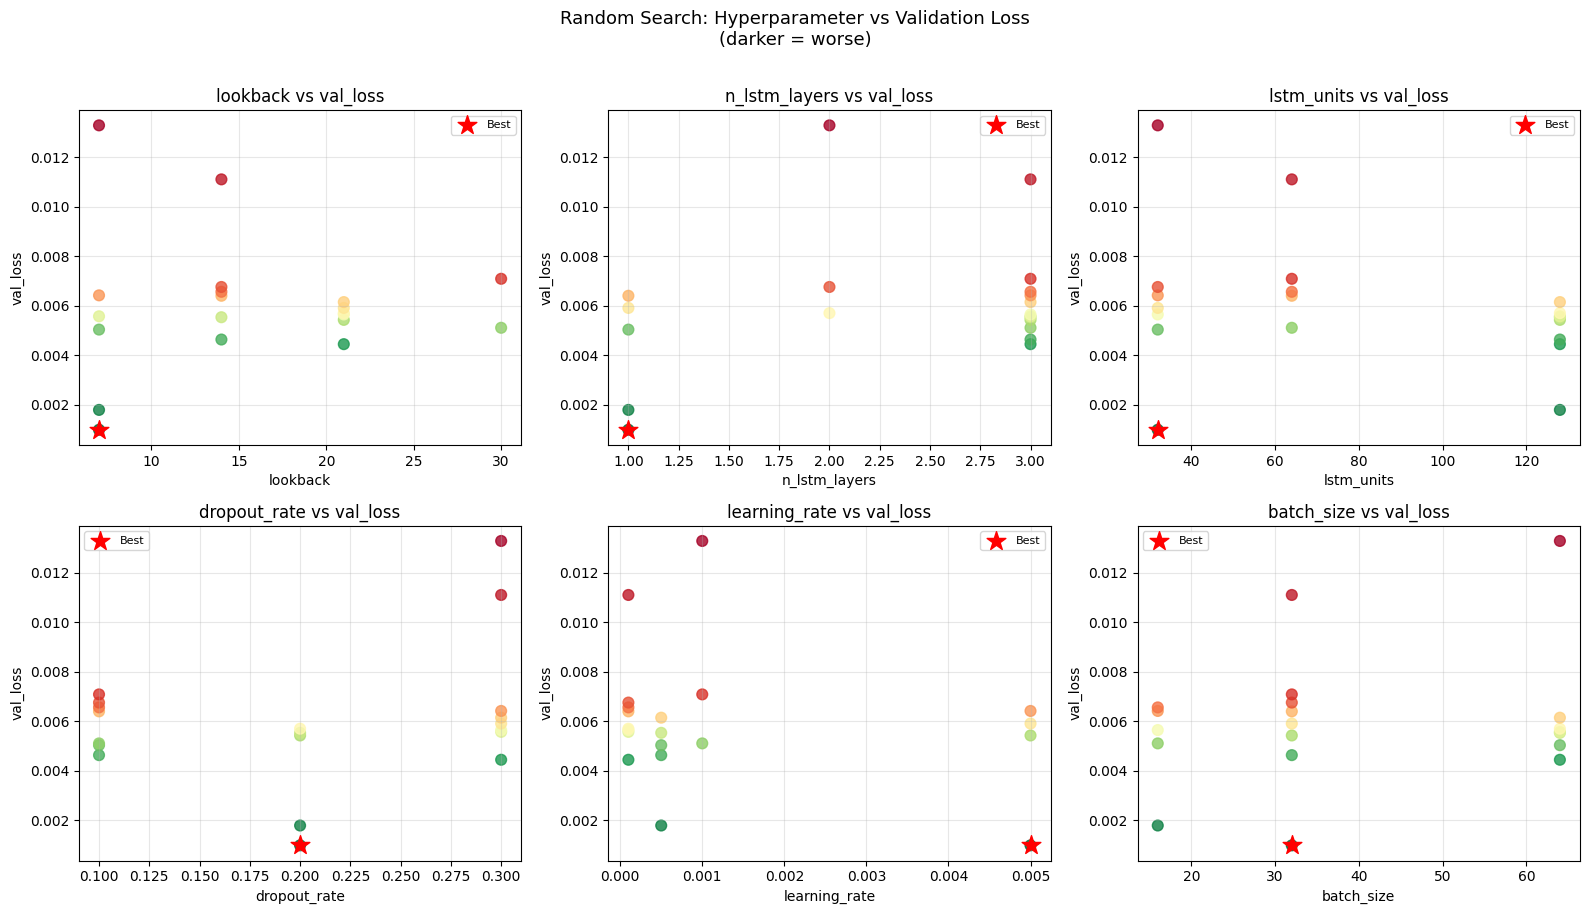

Saved: random_search_results.png


In [12]:
# ── Visualise search results ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

hp_to_plot = ['lookback', 'n_lstm_layers', 'lstm_units',
              'dropout_rate', 'learning_rate', 'batch_size']

for ax, hp in zip(axes.ravel(), hp_to_plot):
    ax.scatter(df_results[hp], df_results['val_loss'],
               c=df_results.index, cmap='RdYlGn_r', s=60, alpha=0.8)
    # Mark the best trial
    ax.scatter(BEST_PARAMS[hp], best_row['val_loss'],
               color='red', s=200, marker='*', zorder=5, label='Best')
    ax.set_xlabel(hp)
    ax.set_ylabel('val_loss')
    ax.set_title(f'{hp} vs val_loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Random Search: Hyperparameter vs Validation Loss\n(darker = worse)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('random_search_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: random_search_results.png")

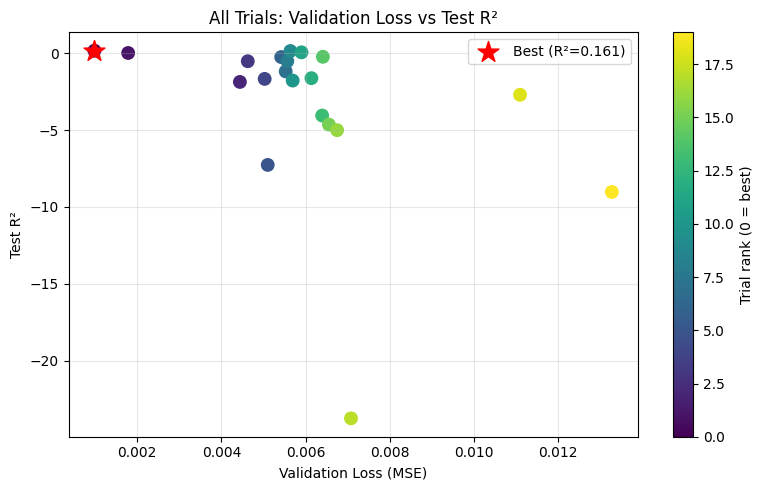

In [13]:
# ── R² vs val_loss scatter for all trials ────────────────────────────────────
plt.figure(figsize=(8, 5))
sc = plt.scatter(df_results['val_loss'], df_results['r2'],
                 c=range(len(df_results)), cmap='viridis', s=80)
plt.scatter(best_row['val_loss'], best_row['r2'],
            color='red', s=250, marker='*', zorder=5, label=f'Best (R²={best_row["r2"]:.3f})')
plt.colorbar(sc, label='Trial rank (0 = best)')
plt.xlabel('Validation Loss (MSE)')
plt.ylabel('Test R²')
plt.title('All Trials: Validation Loss vs Test R²')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## CELL 8 — Final Training with Best Hyperparameters

Now we train the final model properly:
- Full 300 epochs (not capped at 100)
- 90/10 train-test split
- EarlyStopping with patience=25

In [14]:
print("Building final dataset with best lookback =", BEST_PARAMS['lookback'])

X_tr, y_tr, X_te, y_te, sy_final = build_dataset(
    df, FEATURE_COLS, TARGET_COL,
    lookback=BEST_PARAMS['lookback'],
    train_frac=0.90
)

print(f"Train sequences : {X_tr.shape}")
print(f"Test  sequences : {X_te.shape}")

Building final dataset with best lookback = 7
Train sequences : (1058, 7, 20)
Test  sequences : (119, 7, 20)


In [15]:
n_features_final = X_tr.shape[2]
final_model = build_model(BEST_PARAMS, n_features_final)
final_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_47 (LSTM)                  │ (None, 32)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,185 (28.07 KB)

 Trainable params: 7,121 (27.82 KB)

 Non-trainable params: 64 (256.00 B)

In [16]:
final_callbacks = [
    EarlyStopping(monitor='val_loss', patience=25,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-6, verbose=1)
]

final_history = final_model.fit(
    X_tr, y_tr,
    epochs=300,
    batch_size=BEST_PARAMS['batch_size'],
    validation_split=0.12,
    callbacks=final_callbacks,
    verbose=1
)

Epoch 1/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.2847 - mae: 0.3877 - val_loss: 0.0051 - val_mae: 0.0364 - learning_rate: 0.0050
Epoch 2/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0512 - mae: 0.1660 - val_loss: 0.0071 - val_mae: 0.0384 - learning_rate: 0.0050
Epoch 3/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0256 - mae: 0.1165 - val_loss: 0.0065 - val_mae: 0.0352 - learning_rate: 0.0050
Epoch 4/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0177 - mae: 0.0963 - val_loss: 0.0065 - val_mae: 0.0354 - learning_rate: 0.0050
Epoch 5/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0111 - mae: 0.0779 - val_loss: 0.0060 - val_mae: 0.0341 - learning_rate: 0.0050
Epoch 6/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0086 - mae: 0.0669 - val_loss: 0.0061 - val_mae: 0.0339 - learning_rate: 0.0050
Epoch 7/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0073 - mae: 0.0612 - val_loss: 0.0057 - val_mae: 0.0362 - learning_rate: 0.0050
Epoch 8/300


---
## CELL 9 — Final Evaluation

In [17]:
# Predict and inverse-transform (un-MinMax, then un-log1p)
y_pred_sc  = final_model.predict(X_te)
y_pred_log = sy_final.inverse_transform(y_pred_sc)
y_true_log = sy_final.inverse_transform(y_te.reshape(-1, 1))

y_pred_orig = np.expm1(y_pred_log)
y_true_orig = np.expm1(y_true_log)

final_mae  = mean_absolute_error(y_true_orig, y_pred_orig)
final_rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
final_r2   = r2_score(y_true_orig, y_pred_orig)
log_r2     = r2_score(y_true_log, y_pred_log)

print("="*50)
print("  FINAL MODEL RESULTS")
print("="*50)
print(f"  Test MAE  (original scale) : {final_mae:.6f}")
print(f"  Test RMSE (original scale) : {final_rmse:.6f}")
print(f"  Test R²   (original scale) : {final_r2:.4f}")
print(f"  Test R²   (log scale)      : {log_r2:.4f}")
print("="*50)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
  FINAL MODEL RESULTS
  Test MAE  (original scale) : 0.010462
  Test RMSE (original scale) : 0.014937
  Test R²   (original scale) : 0.7734
  Test R²   (log scale)      : 0.7730


---
## CELL 10 — Plots

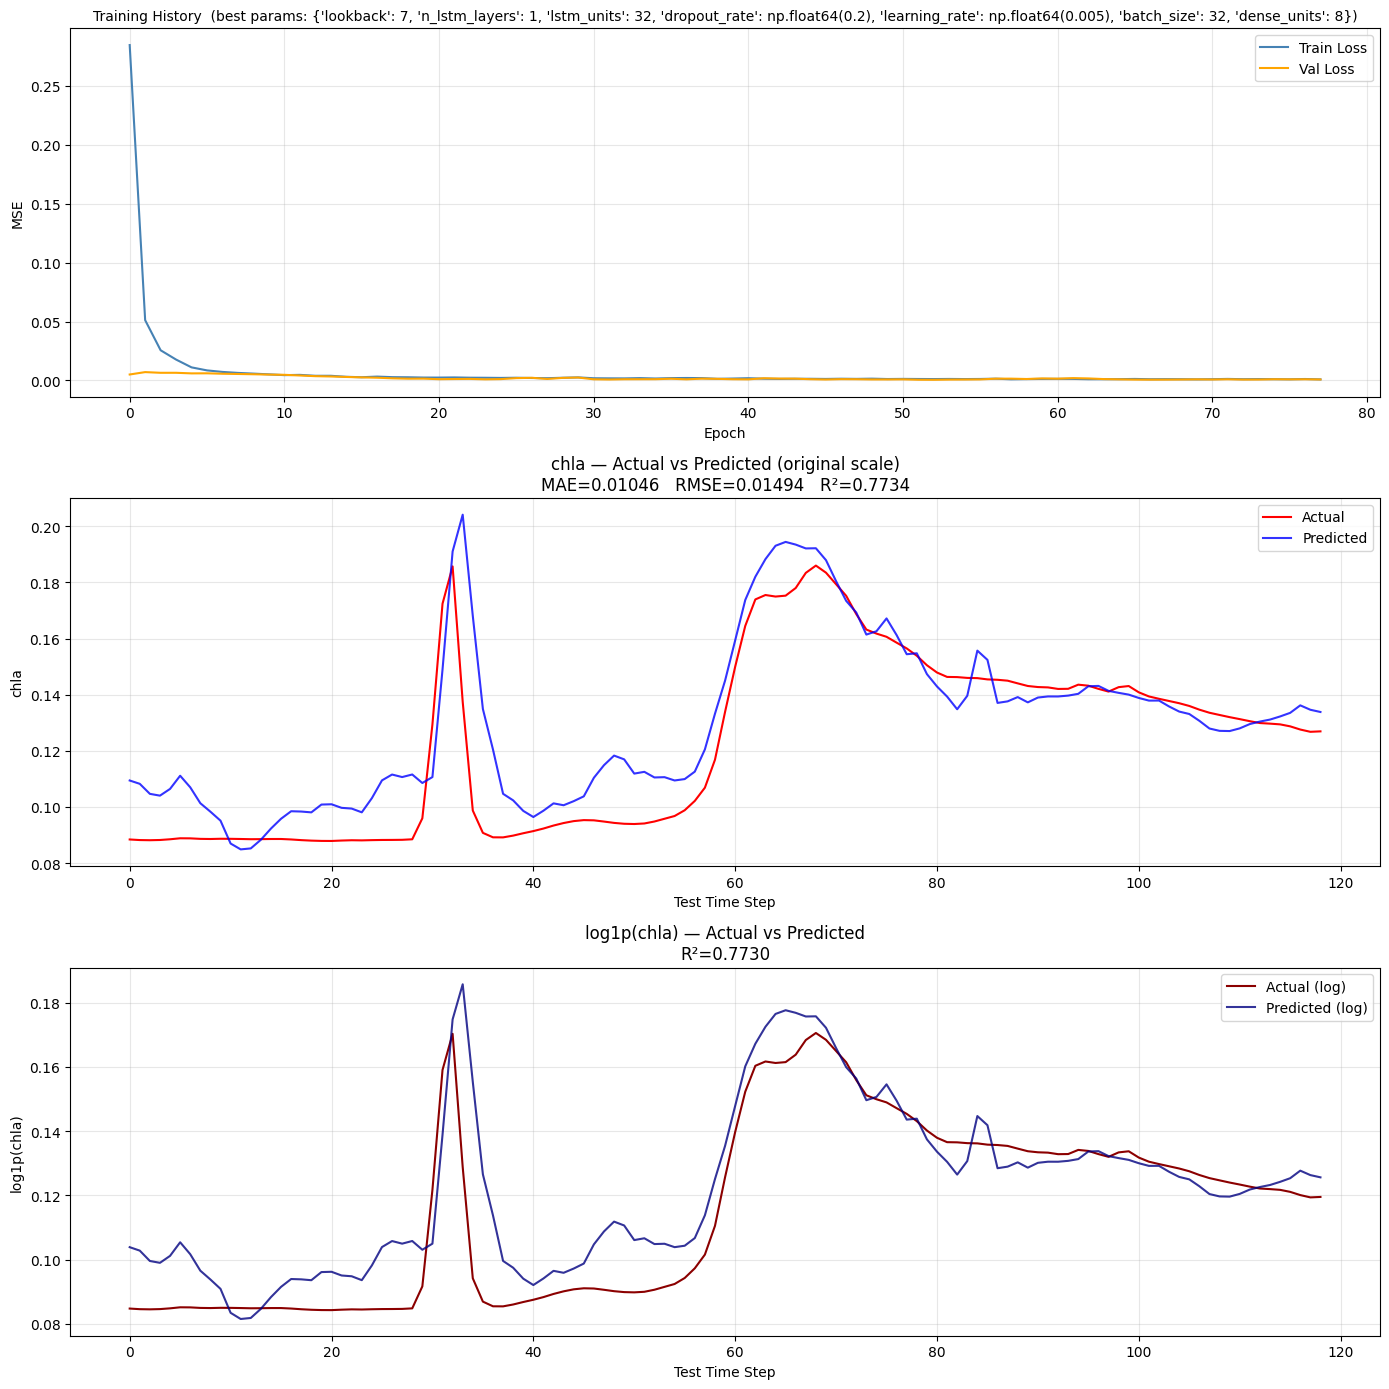

Saved: final_model_results.png


In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# ── Training loss ────────────────────────────────────────────────────────────
axes[0].plot(final_history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(final_history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title(f'Training History  (best params: {BEST_PARAMS})', fontsize=10)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── Actual vs Predicted (original scale) ─────────────────────────────────────
axes[1].plot(y_true_orig, label='Actual',    color='red',  lw=1.5)
axes[1].plot(y_pred_orig, label='Predicted', color='blue', lw=1.5, alpha=0.8)
axes[1].set_title(
    f'chla — Actual vs Predicted (original scale)\n'
    f'MAE={final_mae:.5f}   RMSE={final_rmse:.5f}   R²={final_r2:.4f}'
)
axes[1].set_xlabel('Test Time Step'); axes[1].set_ylabel('chla')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── Actual vs Predicted (log scale) ──────────────────────────────────────────
axes[2].plot(y_true_log, label='Actual (log)',    color='darkred', lw=1.5)
axes[2].plot(y_pred_log, label='Predicted (log)', color='navy',    lw=1.5, alpha=0.8)
axes[2].set_title(
    f'log1p(chla) — Actual vs Predicted\n'
    f'R²={log_r2:.4f}'
)
axes[2].set_xlabel('Test Time Step'); axes[2].set_ylabel('log1p(chla)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_model_results.png")

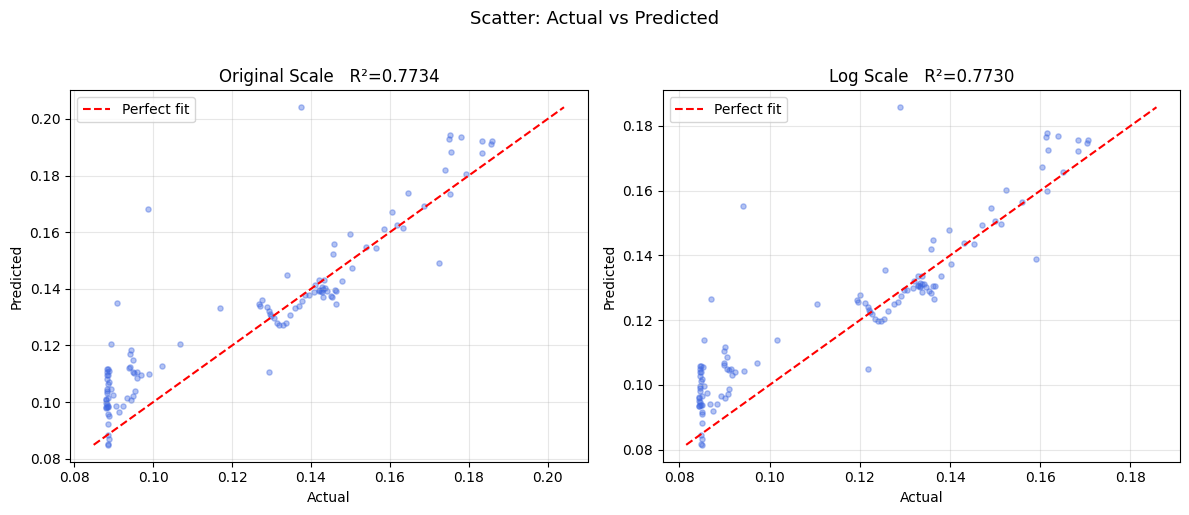

In [20]:
# Scatter: Actual vs Predicted (both scales)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, yt, yp, title in [
    (axes[0], y_true_orig.ravel(), y_pred_orig.ravel(), 'Original Scale'),
    (axes[1], y_true_log.ravel(),  y_pred_log.ravel(),  'Log Scale')
]:
    ax.scatter(yt, yp, alpha=0.4, s=14, color='royalblue')
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
    r2v = r2_score(yt, yp)
    ax.set_title(f'{title}   R²={r2v:.4f}')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Scatter: Actual vs Predicted', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## CELL 11 — Summary Report

In [21]:
print("\n" + "="*60)
print("  RANDOM SEARCH — FULL SUMMARY")
print("="*60)
print(f"  Trials run          : {len(df_results)} / {N_TRIALS}")
print(f"  Search space size   : {total:,} combinations")
print(f"  Coverage            : {len(df_results)/total*100:.2f}%")
print()
print("  BEST HYPERPARAMETERS:")
for k, v in BEST_PARAMS.items():
    print(f"    {k:<20}: {v}")
print()
print("  FINAL MODEL TEST PERFORMANCE:")
print(f"    MAE  (original scale) : {final_mae:.6f}")
print(f"    RMSE (original scale) : {final_rmse:.6f}")
print(f"    R²   (original scale) : {final_r2:.4f}")
print(f"    R²   (log scale)      : {log_r2:.4f}")
print()
print("  Preprocessing applied:")
print("    - log1p(chla) as training target")
print("    - Cyclic time features: month_sin/cos, doy_sin/cos")
print("    - Lag features: chla_log_lag1/2/3")
print("    - MinMaxScaler fit on train only (no data leakage)")
print("    - Test sequences prepend last LOOKBACK scaled train rows")
print("="*60)


  RANDOM SEARCH — FULL SUMMARY
  Trials run          : 20 / 20
  Search space size   : 3,888 combinations
  Coverage            : 0.51%

  BEST HYPERPARAMETERS:
    lookback            : 7
    n_lstm_layers       : 1
    lstm_units          : 32
    dropout_rate        : 0.2
    learning_rate       : 0.005
    batch_size          : 32
    dense_units         : 8

  FINAL MODEL TEST PERFORMANCE:
    MAE  (original scale) : 0.010462
    RMSE (original scale) : 0.014937
    R²   (original scale) : 0.7734
    R²   (log scale)      : 0.7730

  Preprocessing applied:
    - log1p(chla) as training target
    - Cyclic time features: month_sin/cos, doy_sin/cos
    - Lag features: chla_log_lag1/2/3
    - MinMaxScaler fit on train only (no data leakage)
    - Test sequences prepend last LOOKBACK scaled train rows
